In [ ]:
import scanpy as sc
import os

In [ ]:
adata = sc.read_h5ad('../data/mtDNA_DSB_5k_clustered_annotation_with_rbd_OL_updated.h5ad')

In [ ]:
OLD = ['Oligodendrocytes',
 'Excitatory Neurons',
 'Astrocytes',
 'Microglia',
 'Neurons',
 'Endothelial Cells',
 'GABAergic Neurons',
 'Immature Oligodendrocytes I',
 'Neural Stem Cells',
 'Immature Oligodendrocytes III',
 'Immature Oligodendrocytes II',
 'Medium Spiny Neurons',
 'Immature Oligodendrocytes IV',
 'Endocrine Cells',
 'Myocytes',
 'DA-Oligodendrocytes']

In [ ]:
NEW =['Oligodendrocytes',
 'Excitatory Neurons',
 'Astrocytes',
 'Microglia',
 'Neurons',
 'Endothelial Cells',
 'GABAergic Neurons',
 'Immature Oligodendrocytes',
 'Neural Stem Cells',
 'Immature Oligodendrocytes',
 'Immature Oligodendrocytes',
 'Medium Spiny Neurons',
 'Immature Oligodendrocytes',
 'Endocrine Cells',
 'Myocytes',
 'DA-Oligodendrocytes']

In [ ]:
adata.obs['cell_class_updated'] = adata.obs['cell_class'].replace(OLD, NEW)

/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_2929/3268940889.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs['cell_class_updated'] = adata.obs['cell_class'].replace(OLD, NEW)


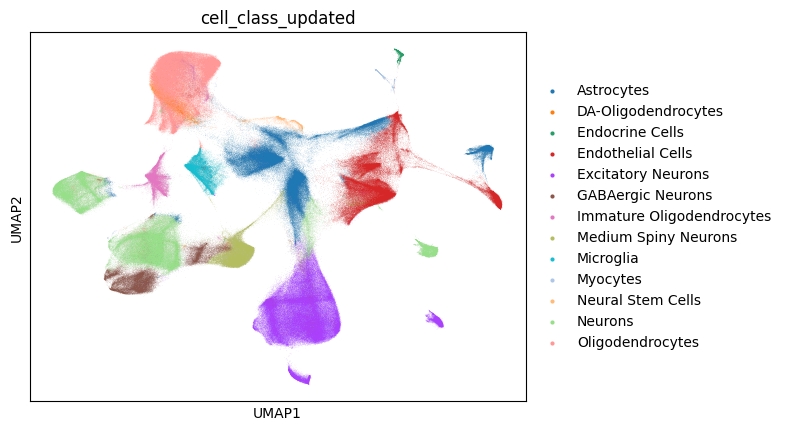

In [ ]:
sc.pl.umap(adata, color = 'cell_class_updated')

In [ ]:
outdir = "../results/cell_types_updated_all_subset"
os.makedirs(outdir)

FileExistsError: [Errno 17] File exists: '../results/cell_types_updated_all'

In [17]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec

def plot_spatial_compact(
    ad,
    color="leiden_2",
    groupby="sample_id",
    spot_size=18,
    cols=3,
    height=8,
    legend_col_width=1.2,
    palette=None,          # <- NEW: dict {category: "#hex"} or list in desired order
):
    # --- categories from the FULL object (freeze order) ---
    cats = ad.obs[color].astype("category").cat.categories

    # --- build a shared color list in that order ---
    if isinstance(palette, dict):
        cols_list = [palette[c] for c in cats]
    elif isinstance(palette, (list, tuple)):
        if len(palette) < len(cats):
            raise ValueError("Palette list shorter than number of categories.")
        cols_list = list(palette)[:len(cats)]
    elif f"{color}_colors" in ad.uns:
        # reuse existing palette if present on the full object
        cols_list = list(ad.uns[f"{color}_colors"])
        if len(cols_list) != len(cats):
            raise ValueError(f"{color}_colors length does not match categories.")
    else:
        base = sc.pl.palettes.default_64 if hasattr(sc.pl.palettes, "default_64") else sc.pl.palettes.default_102
        reps = int(np.ceil(len(cats) / len(base)))
        cols_list = (base * reps)[:len(cats)]

    # store on the full object too (handy if you plot elsewhere later)
    ad.uns[f"{color}_colors"] = cols_list

    # --- layout ---
    sids = list(ad.obs[groupby].unique())
    n = len(sids)
    rows = int(np.ceil(n / cols))

    panel_w = height * cols * 0.6 / rows
    fig_w = panel_w + legend_col_width
    fig = plt.figure(figsize=(fig_w, height), constrained_layout=False)

    gs = GridSpec(
        rows, cols + 1, figure=fig,
        width_ratios=[1]*cols + [legend_col_width / (fig_w - legend_col_width)],
        wspace=0.02, hspace=0.02
    )

    # --- panels ---
    for i, sid in enumerate(sids):
        r, c = divmod(i, cols)
        ax = fig.add_subplot(gs[r, c])

        ad_sub = ad[ad.obs[groupby] == sid].copy()

        # CRUCIAL: force identical categories & palette on each subset
        ad_sub.obs[color] = ad_sub.obs[color].astype("category")
        ad_sub.obs[color] = ad_sub.obs[color].cat.set_categories(cats)
        ad_sub.uns[f"{color}_colors"] = cols_list

        sc.pl.spatial(
            ad_sub, color=color, spot_size=spot_size,
            show=False, ax=ax, legend_loc=None, frameon=False, title=str(sid)
        )
        ax.set_xlabel(""); ax.set_ylabel("")
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    # blank unused
    for j in range(n, rows*cols):
        r, c = divmod(j, cols)
        fig.add_subplot(gs[r, c]).axis("off")

    # --- legend ---
    ax_leg = fig.add_subplot(gs[:, -1])
    ax_leg.axis("off")
    handles = [
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor=cols_list[k], markersize=7, label=str(cat))
        for k, cat in enumerate(cats)
    ]
    ax_leg.legend(handles=handles, title=color, frameon=False, loc="center left")

    fig.subplots_adjust(left=0.01, right=0.98, top=0.98, bottom=0.02, wspace=0.02, hspace=0.02)
    plt.show()

import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
from matplotlib.gridspec import GridSpec
from matplotlib.colors import Normalize

def plot_spatial_genes_compact(
    ad,
    genes,
    groupby="sample_id",
    spot_size=18,
    cols=3,
    height=8,
    cmap="magma",          # any matplotlib colormap
    log1p=False,           # log1p-transform before plotting
    robust=True,           # use robust 2–98% limits instead of min/max
    vmin=None, vmax=None,  # override global color limits if you want
    nan_color="lightgray", # background for zero/NaN
    title_suffix="",
):
    """
    Plot per-sample spatial maps for one or multiple genes (continuous).
    Uses a shared color scale across all samples for each gene.
    """

    # ensure genes is a list
    genes = [genes] if isinstance(genes, str) else list(genes)
    sids  = list(ad.obs[groupby].unique())
    nS, nG = len(sids), len(genes)

    # grid: rows = samples, cols = genes + 1 legend column
    cols_total = nG + 1
    rows = int(np.ceil(nS))
    fig = plt.figure(figsize=(height * cols_total * 0.6, height), constrained_layout=False)
    gs  = GridSpec(rows, cols_total, figure=fig, width_ratios=[1]*nG + [0.25],
                   wspace=0.03, hspace=0.03)

    for gi, g in enumerate(genes):
        if g not in ad.var_names:
            print(f"⚠️ Gene '{g}' not in var_names; skipping.")
            continue

        # collect values across ALL samples to set shared limits
        vals = ad[:, g].X
        vals = vals.toarray().ravel() if hasattr(vals, "toarray") else np.asarray(vals).ravel()
        if log1p: vals = np.log1p(vals)

        if vmin is None or vmax is None:
            if robust:
                lo, hi = np.nanpercentile(vals, [2, 98])
            else:
                lo, hi = np.nanmin(vals), np.nanmax(vals)
        else:
            lo, hi = vmin, vmax
        if hi <= lo:  # degenerate case
            hi = lo + 1e-9
        norm = Normalize(vmin=lo, vmax=hi)

        # draw per-sample panels for this gene
        for si, sid in enumerate(sids):
            ax = fig.add_subplot(gs[si, gi]) if rows > 1 else fig.add_subplot(gs[0, gi])
            ad_sub = ad[ad.obs[groupby] == sid].copy()

            # precompute color values so Scanpy respects global norm
            v = ad_sub[:, g].X
            v = v.toarray().ravel() if hasattr(v, "toarray") else np.asarray(v).ravel()
            if log1p: v = np.log1p(v)
            # map to colors
            cmap_obj = plt.get_cmap(cmap)
            rgba = cmap_obj(norm(v))
            # make zeros / NaNs pale
            mask = ~np.isfinite(v) | (v <= 0)
            rgba[mask, :3] = plt.matplotlib.colors.to_rgb(nan_color)  # set color
            rgba[mask, 3]  = 1.0                                     # opaque

            # Scanpy trick: provide precomputed colors via obs (as hex)
            import matplotlib.colors as mcolors
            hex_colors = [mcolors.to_hex(c) for c in rgba]
            ad_sub.obs[f"__{g}__colors"] = hex_colors

            sc.pl.spatial(
                ad_sub,
                color=f"__{g}__colors",           # plot with our precomputed colors
                spot_size=spot_size,
                show=False,
                ax=ax,
                title=f"{sid}" + (f" • {title_suffix}" if title_suffix else ""),
                frameon=False,
                legend_loc=None,
            )
            ax.set_xlabel(""); ax.set_ylabel("")
            ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

        # add a colorbar column only once per gene
        cb_ax = fig.add_subplot(gs[:, -1]) if rows > 1 else fig.add_subplot(gs[0, -1])
        if gi == nG - 1:  # only draw once (last gene) to avoid redraw
            cb_ax.axis("off")
            sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
            sm.set_array([])
            cbar = fig.colorbar(sm, ax=cb_ax, fraction=0.8)
            cbar.set_label(f"{'log1p(' if log1p else ''}{genes[-1]}{')' if log1p else ''}", rotation=90)

    fig.subplots_adjust(left=0.02, right=0.98, top=0.96, bottom=0.02, wspace=0.02, hspace=0.02)
    plt.show()


def plot_spatial_any(
    ad,
    feature,
    **kwargs
):
    """
    Convenience dispatcher:
      - If `feature` is a column in .obs (categorical), call plot_spatial_compact
      - If `feature` is a gene (in .var_names), call plot_spatial_genes_compact
    """
    if feature in ad.obs.columns and pd.api.types.is_categorical_dtype(ad.obs[feature]):
        return plot_spatial_compact(ad, color=feature, **kwargs)
    elif feature in ad.var_names:
        return plot_spatial_genes_compact(ad, genes=feature, **kwargs)
    else:
        raise ValueError(f"'{feature}' not found as categorical obs or gene.")

import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np

def plot_spatial_highlight(
    ad,
    color="rbd_domain_0.5",
    highlight=None,            # one or multiple categories to highlight
    groupby="sample_id",
    spot_size=18,
    cols=3,
    height=8,
    base_color="lightgrey",
    highlight_color=None,      # auto from palette if None
):
    """
    Plot one or several clusters highlighted in color, others grey.
    """

    if highlight is None:
        raise ValueError("Please specify at least one value in `highlight`")

    # make a copy to avoid modifying original
    ad = ad.copy()
    vals = ad.obs[color].astype(str)

    # identify highlight set
    highlight = [highlight] if isinstance(highlight, str) else list(highlight)
    mask = vals.isin(highlight)

    # define colors
    # reuse existing palette if present
    if f"{color}_colors" in ad.uns:
        pal = dict(zip(ad.obs[color].cat.categories, ad.uns[f"{color}_colors"]))
    else:
        base = getattr(sc.pl.palettes, "default_102", sc.pl.palettes.vega_20)
        cats = ad.obs[color].astype("category").cat.categories
        reps = int(np.ceil(len(cats)/len(base)))
        all_colors = (base * reps)[:len(cats)]
        pal = dict(zip(cats, all_colors))

    # pick one highlight color (first of list)
    if highlight_color is None:
        highlight_color = pal.get(highlight[0], "#d62728")  # fallback red

    # new column for plotting
    ad.obs["_highlight_plot_"] = np.where(mask, highlight[0], "other")
    ad.obs["_highlight_plot_"] = ad.obs["_highlight_plot_"].astype("category")

    # define palette for two classes: highlighted + grey
    palette = {"other": base_color, highlight[0]: highlight_color}

    # use your existing compact plot function
    plot_spatial_compact(
        ad,
        color="_highlight_plot_",
        groupby=groupby,
        spot_size=spot_size,
        cols=cols,
        height=height,
        palette=palette
    )

import numpy as np
import os
import matplotlib.pyplot as plt
import scanpy as sc

def _flip_y_inplace(ad):
    """Flip Y in .obsm['spatial'] so 'up' is up."""
    XY = ad.obsm["spatial"].copy()
    XY[:, 1] = XY[:, 1].max() - XY[:, 1]
    ad.obsm["spatial"] = XY
    return ad

def _flip_x_inplace(ad):
    """Flip X in .obsm['spatial'] so left/right matches."""
    XY = ad.obsm["spatial"].copy()
    XY[:, 0] = XY[:, 0].max() - XY[:, 0]
    ad.obsm["spatial"] = XY
    return ad

def plot_spatial_highlight(
    adata,
    color="rbd_domain_0.5",
    highlight=None,
    groupby="sample_id",
    spot_size=18,
    cols=3,
    height=7,
    grey="#D9D9D9",
    cmap_highlight=None,
    flip_y=True,          # <- NEW: flip coordinates, not axes
    fix_limits=True,      # <- NEW: keep consistent x/y limits across panels
    flip_x_samples=None,  # <- NEW: flip x for selected samples
    sample_label_map=None # <- NEW: override titles for selected samples
):
    assert highlight is not None, "Provide a `highlight` category to emphasize."
    cats = adata.obs[color].astype("category").cat.categories
    # build a robust palette even if adata.uns is missing/incomplete
    if f"{color}_colors" in adata.uns:
        palette_list = list(adata.uns[f"{color}_colors"])
    else:
        base = getattr(sc.pl.palettes, "default_102", sc.pl.palettes.vega_20)
        reps = int(np.ceil(len(cats)/len(base)))
        palette_list = list((base * reps)[:len(cats)])
    if len(palette_list) < len(cats):
        base = getattr(sc.pl.palettes, "default_102", sc.pl.palettes.vega_20)
        reps = int(np.ceil(len(cats)/len(base)))
        palette_list = list((base * reps)[:len(cats)])
    palette_map = {cat: palette_list[i % len(palette_list)] for i, cat in enumerate(cats)}
    hl_col = (cmap_highlight or palette_map.get(highlight, "#3949ab"))
    sids = list(adata.obs[groupby].unique())
    n, rows = len(sids), int(np.ceil(len(sids)/cols))

    # choose highlight color
    if cmap_highlight is None and f"{color}_colors" in adata.uns and highlight in cats:
        try:
            hl_col = adata.uns[f"{color}_colors"][list(cats).index(highlight)]
        except Exception:
            hl_col = cmap_highlight or "#3949ab"
    else:
        hl_col = cmap_highlight or "#3949ab"

    # global limits (after potential flip) so all axes are identical
    if fix_limits:
        ad_tmp = adata.copy()
        if flip_y:
            _flip_y_inplace(ad_tmp)
        if flip_x_samples:
            XY = ad_tmp.obsm["spatial"].copy()
            for sid in flip_x_samples:
                mask = ad_tmp.obs[groupby] == sid
                if mask.any():
                    sub = XY[mask].copy()
                    sub[:, 0] = sub[:, 0].max() - sub[:, 0]
                    XY[mask] = sub
            ad_tmp.obsm["spatial"] = XY
        X, Y = ad_tmp.obsm["spatial"][:,0], ad_tmp.obsm["spatial"][:,1]
        xlim = (X.min(), X.max())
        ylim = (Y.min(), Y.max())
        del ad_tmp
    else:
        xlim = ylim = None

    fig_w = cols * (height * 0.7); fig_h = height
    fig, axs = plt.subplots(rows, cols, figsize=(fig_w, fig_h), squeeze=False)
    for ax in axs.flat: ax.set_axis_off()

    for i, sid in enumerate(sids):
        r, c = divmod(i, cols)
        ax = axs[r, c]
        ad_sub = adata[adata.obs[groupby] == sid].copy()
        if flip_y:
            _flip_y_inplace(ad_sub)
        if flip_x_samples and sid in flip_x_samples:
            _flip_x_inplace(ad_sub)

        # masks
        mask_hi = (ad_sub.obs[color] == highlight)
        mask_lo = ~mask_hi

        # background (grey)
        if mask_lo.sum():
            sc.pl.spatial(ad_sub[mask_lo], color=None, spot_size=spot_size,
                          show=False, ax=ax, frameon=False)
            coll = ax.collections[-1]
            coll.set_facecolor(grey); coll.set_edgecolor("none")

        # highlight (colored)
        if mask_hi.sum():
            plt.rcParams["scatter.marker"] = "."
            plt.rcParams["patch.linewidth"] = 0

            sc.pl.spatial(ad_sub[mask_hi], color=None, spot_size=spot_size,
                          show=False, ax=ax, frameon=False)
            coll = ax.collections[-1]
            coll.set_facecolor(hl_col); coll.set_edgecolor("none")

        # lock limits so panels align
        if xlim: ax.set_xlim(*xlim)
        if ylim: ax.set_ylim(*ylim)

        label = sample_label_map.get(sid, sid) if sample_label_map else sid
        ax.set_title(f"{label} • {color}={highlight}", fontsize=10)

    # blank unused
    for j in range(n, rows*cols):
        r, c = divmod(j, cols)
        axs[r, c].axis("off")

    plt.tight_layout()
    return fig, axs



In [19]:
import os
import matplotlib.pyplot as plt

domain_key = "cell_class_updated"
sample_label_map = {"RB4627": "PLP:mtPstI", "RB4676": "Control"}
flip_x_samples = {"RB4676"}
os.makedirs(outdir, exist_ok=True)

for cl in adata.obs[domain_key].astype("category").cat.categories:
    if str(cl).lower().startswith("myocyte"):
        print(f"⏭️ Skipping {cl} — excluded from plotting")
        continue
    if str(cl).lower().startswith("endocrine"):
        print(f"⏭️ Skipping {cl} — excluded from plotting")
        continue
    # handle special case name
    cl_name = "meninges" if cl == "Meningeal border/glia limitans" else cl
    outpath = os.path.join(outdir, f"{domain_key}_cluster_{cl_name}.png")

    # skip if file already exists
    if os.path.exists(outpath):
        print(f"⏭️ Skipping {cl_name} — already saved at {outpath}")
        continue

    # generate plot
    print(f"🖼️ Generating {cl_name}...")
    try:
        fig, _ = plot_spatial_highlight(
            adata, color=domain_key, highlight=cl,
            groupby="sample_id", spot_size=30, cols=2, height=8,
            flip_y=True, fix_limits=True,
            flip_x_samples=flip_x_samples, sample_label_map=sample_label_map
        )
    except Exception as e:
        print(f"⚠️ Skipping {cl_name} due to error: {e}")
        continue

    # save plot
    fig.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.close(fig)
    print(f"✅ Saved → {outpath}")


🖼️ Generating Astrocytes...


/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_5834/3997499450.py:380: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad_sub[mask_lo], color=None, spot_size=spot_size,
/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_5834/3997499450.py:390: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad_sub[mask_hi], color=None, spot_size=spot_size,
/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_5834/3997499450.py:380: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad_sub[mask_lo], color=None, spot_size=spot_size,
/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_5834/3997499450.py:390: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad_sub[mask_hi], color=None, spot_size=spot_size,


✅ Saved → ../results/cell_types_updated_all_subset/cell_class_updated_cluster_Astrocytes.png
🖼️ Generating DA-Oligodendrocytes...


/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_5834/3997499450.py:380: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad_sub[mask_lo], color=None, spot_size=spot_size,
/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_5834/3997499450.py:390: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad_sub[mask_hi], color=None, spot_size=spot_size,
/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_5834/3997499450.py:380: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad_sub[mask_lo], color=None, spot_size=spot_size,
/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_5834/3997499450.py:390: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad_sub[mask_hi], color=None, spot_size=spot_size,


✅ Saved → ../results/cell_types_updated_all_subset/cell_class_updated_cluster_DA-Oligodendrocytes.png
⏭️ Skipping Endocrine Cells — excluded from plotting
🖼️ Generating Endothelial Cells...


...

✅ Saved → ../results/cell_types_updated_all_subset/cell_class_updated_cluster_Neural Stem Cells.png
🖼️ Generating Neurons...


/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_5834/3997499450.py:380: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad_sub[mask_lo], color=None, spot_size=spot_size,
/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_5834/3997499450.py:390: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad_sub[mask_hi], color=None, spot_size=spot_size,
/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_5834/3997499450.py:380: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad_sub[mask_lo], color=None, spot_size=spot_size,
/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_5834/3997499450.py:390: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad_sub[mask_hi], color=None, spot_size=spot_size,


✅ Saved → ../results/cell_types_updated_all_subset/cell_class_updated_cluster_Neurons.png
🖼️ Generating Oligodendrocytes...


/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_5834/3997499450.py:380: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad_sub[mask_lo], color=None, spot_size=spot_size,
/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_5834/3997499450.py:390: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad_sub[mask_hi], color=None, spot_size=spot_size,
/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_5834/3997499450.py:380: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad_sub[mask_lo], color=None, spot_size=spot_size,
/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_5834/3997499450.py:390: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad_sub[mask_hi], color=None, spot_size=spot_size,


✅ Saved → ../results/cell_types_updated_all_subset/cell_class_updated_cluster_Oligodendrocytes.png


In [21]:
import os, re, numpy as np
from PIL import Image
import imageio.v3 as iio

def natural_key(s):
    m = re.search(r'(\d+)', os.path.basename(s))
    return int(m.group(1)) if m else s

def load_and_pad(paths, bg="white", scale=0.5):
    imgs, sizes = [], []
    for p in paths:
        im = Image.open(p).convert("RGB")
        # ↓ downscale early for smaller memory footprint
        if scale != 1.0:
            w, h = im.size
            im = im.resize((int(w * scale), int(h * scale)), Image.Resampling.LANCZOS)
        imgs.append(im)
        sizes.append(im.size)

    max_w = max(w for w, h in sizes)
    max_h = max(h for w, h in sizes)

    padded = []
    for im in imgs:
        w, h = im.size
        canvas = Image.new("RGB", (max_w, max_h), color=bg)
        canvas.paste(im, ((max_w - w)//2, (max_h - h)//2))
        padded.append(np.asarray(canvas))
    return padded

# === CONFIG ===
img_dir  = "../results/cell_types_updated_all_subset"
gif_path = os.path.join(img_dir, "cell_types_all_small.gif")

files = [os.path.join(img_dir, f) for f in os.listdir(img_dir) if f.endswith(".png")]
files = [f for f in files if os.path.getsize(f) > 1024]
#files = sorted(files, key=lambda x: int(re.search(r'RBD(\d+)', x).group(1)))
files = sorted(files)
if not files:
    raise RuntimeError(f"No PNGs found in {img_dir}")

# ↓ make it smaller and faster
frames = load_and_pad(files, bg="white", scale=0.4)

# ↓ lower resolution, faster playback (200–400 ms per frame)
iio.imwrite(
    gif_path,
    frames,
    duration=900,   # ms per frame
    loop=0,         # infinite loop
    palettesize=64, # smaller color palette → smaller file
)

print(f"✅ Saved {len(frames)} frames to {gif_path}")

✅ Saved 11 frames to ../results/cell_types_updated_all_subset/cell_types_all_small.gif
